<a href="https://colab.research.google.com/github/Kunal890498/Advanced-Banking-Management-Sytem/blob/main/Vote__Analysis_task_5_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")

print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in the downloaded dataset!")

csv_path = os.path.join(path, csv_files[0])
print(f"Loading file: {csv_files[0]}")

100%|██████████| 89.0M/89.0M [00:00<00:00, 106MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/himanshupoddar/zomato-bangalore-restaurants/versions/1
Loading file: zomato.csv


In [ ]:
print("\n--- Step 2: Loading and Inspecting Data ---")

df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())



--- Step 2: Loading and Inspecting Data ---
Dataset shape: 51717 rows, 17 columns

First 5 rows:
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Ye

In [ ]:
print("\n--- Step 3: Data Cleaning ---")

rate_col = None
votes_col = None
cost_col = None
name_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'rate' in col_lower or 'rating' in col_lower:
        rate_col = col
    if 'vote' in col_lower or 'num of ratings' in col_lower:
        votes_col = col
    if 'cost' in col_lower or 'avg cost' in col_lower or 'approx_cost' in col_lower:
        cost_col = col
    if 'name' in col_lower:
        name_col = col

if rate_col is None:

    for col in ['rate', 'rating', 'aggregate rating']:
        if col in df.columns:
            rate_col = col
            break

if votes_col is None:
    for col in ['votes', 'num of ratings']:
        if col in df.columns:
            votes_col = col
            break

if name_col is None:
    for col in ['name', 'restaurant name']:
        if col in df.columns:
            name_col = col
            break

if rate_col is None or votes_col is None:
    raise ValueError(f"Could not find required columns. Available columns: {df.columns.tolist()}")

print(f"Using columns:")
print(f"  - Name: '{name_col}'")
print(f"  - Rate: '{rate_col}'")
print(f"  - Votes: '{votes_col}'")
print(f"  - Cost: '{cost_col}'")


--- Step 3: Data Cleaning ---
Using columns:
  - Name: 'name'
  - Rate: 'rate'
  - Votes: 'votes'
  - Cost: 'approx_cost(for two people)'


In [ ]:

if df[rate_col].dtype == 'object':
    df['rating'] = df[rate_col].str.split('/').str[0]
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
else:
    df['rating'] = df[rate_col].astype(float)

df['votes'] = pd.to_numeric(df[votes_col], errors='coerce')

df_clean = df.dropna(subset=['rating', 'votes']).copy()

df_clean = df_clean[df_clean['votes'] > 0]

print(f"Rows after cleaning: {df_clean.shape[0]}")
print(f"Rating range: {df_clean['rating'].min():.1f} - {df_clean['rating'].max():.1f}")
print(f"Votes range: {df_clean['votes'].min():.0f} - {df_clean['votes'].max():.0f}")


Rows after cleaning: 41646
Rating range: 1.8 - 4.9
Votes range: 1 - 16832


In [ ]:
print("\n" + "=" * 60)
print("TASK 5.1: Restaurants with Highest and Lowest Votes")
print("=" * 60)

highest_votes_idx = df_clean['votes'].idxmax()
lowest_votes_idx = df_clean['votes'].idxmin()

highest_votes_row = df_clean.loc[highest_votes_idx]
lowest_votes_row = df_clean.loc[lowest_votes_idx]

print(f"\n🏆 HIGHEST VOTES:")
print(f"  Restaurant: {highest_votes_row[name_col] if name_col else 'N/A'}")
print(f"  Votes: {highest_votes_row['votes']}")
print(f"  Rating: {highest_votes_row['rating']:.1f}")

print(f"\n📉 LOWEST VOTES:")
print(f"  Restaurant: {lowest_votes_row[name_col] if name_col else 'N/A'}")
print(f"  Votes: {lowest_votes_row['votes']}")
print(f"  Rating: {lowest_votes_row['rating']:.1f}")


TASK 5.1: Restaurants with Highest and Lowest Votes

🏆 HIGHEST VOTES:
  Restaurant: Byg Brewski Brewing Company
  Votes: 16832
  Rating: 4.9

📉 LOWEST VOTES:
  Restaurant: Tasty Bites
  Votes: 1
  Rating: 3.8


In [ ]:
print("\n" + "=" * 60)
print("TASK 5.2: Correlation between Votes and Rating")
print("=" * 60)

correlation = df_clean['votes'].corr(df_clean['rating'])
print(f"\n📊 Pearson Correlation Coefficient: {correlation:.4f}")

from scipy.stats import pearsonr
p_value = pearsonr(df_clean['votes'], df_clean['rating'])[1]
print(f"P-value: {p_value:.6f}")

print("\n📝 INTERPRETATION:")
if abs(correlation) > 0.7:
    print(f"  Strong {'positive' if correlation > 0 else 'negative'} correlation (r = {correlation:.3f})")
    print(f"  → There is a strong relationship between votes and rating.")
elif abs(correlation) > 0.3:
    print(f"  Moderate {'positive' if correlation > 0 else 'negative'} correlation (r = {correlation:.3f})")
    print(f"  → Restaurants with more votes tend to have {'higher' if correlation > 0 else 'lower'} ratings.")
elif abs(correlation) > 0.1:
    print(f"  Weak correlation (r = {correlation:.3f})")
    print(f"  → Votes and ratings are weakly related.")
else:
    print(f"  Very weak or no correlation (r = {correlation:.3f})")
    print(f"  → Votes and ratings are largely independent.")

if p_value < 0.05:
    print(f"  ✅ This correlation is statistically significant (p < 0.05)")
else:
    print(f"  ❌ This correlation is NOT statistically significant (p ≥ 0.05)")



TASK 5.2: Correlation between Votes and Rating

📊 Pearson Correlation Coefficient: 0.4341
P-value: 0.000000

📝 INTERPRETATION:
  Moderate positive correlation (r = 0.434)
  → Restaurants with more votes tend to have higher ratings.
  ✅ This correlation is statistically significant (p < 0.05)


In [ ]:
print("\n" + "=" * 60)
print("BONUS: Additional Insights")
print("=" * 60)

# Top 5 restaurants by votes
print("\n🏆 TOP 5 RESTAURANTS BY VOTES:")
top_5 = df_clean.nlargest(5, 'votes')[['name', 'votes', 'rating']]
for idx, row in top_5.iterrows():
    print(f"  {row['name']}: {row['votes']} votes, Rating: {row['rating']:.1f}")

# Bottom 5 restaurants by votes (with positive votes)
print("\n📉 BOTTOM 5 RESTAURANTS BY VOTES (excluding zero):")
bottom_5 = df_clean.nsmallest(5, 'votes')[['name', 'votes', 'rating']]
for idx, row in bottom_5.iterrows():
    print(f"  {row['name']}: {row['votes']} votes, Rating: {row['rating']:.1f}")

# Rating distribution by vote count categories
print("\n📊 RATING BY VOTE CATEGORIES:")
bins = [0, 100, 500, 1000, 5000, float('inf')]
labels = ['0-100', '101-500', '501-1000', '1001-5000', '5000+']
df_clean['vote_category'] = pd.cut(df_clean['votes'], bins=bins, labels=labels, right=False)
avg_rating_by_category = df_clean.groupby('vote_category')['rating'].mean().round(2)
for category, rating in avg_rating_by_category.items():
    print(f"  {category} votes: Average rating = {rating}")


BONUS: Additional Insights

🏆 TOP 5 RESTAURANTS BY VOTES:
  Byg Brewski Brewing Company: 16832 votes, Rating: 4.9
  Byg Brewski Brewing Company: 16832 votes, Rating: 4.9
  Byg Brewski Brewing Company: 16832 votes, Rating: 4.9
  Byg Brewski Brewing Company: 16345 votes, Rating: 4.9
  Byg Brewski Brewing Company: 16345 votes, Rating: 4.9

📉 BOTTOM 5 RESTAURANTS BY VOTES (excluding zero):
  Tasty Bites: 1 votes, Rating: 3.8
  Irie: 1 votes, Rating: 3.2
  Height's Cafe - Hotel Bangalore International: 2 votes, Rating: 3.2
  Height's Cafe - Hotel Bangalore International: 2 votes, Rating: 3.2
  Height's Cafe - Hotel Bangalore International: 2 votes, Rating: 3.2

📊 RATING BY VOTE CATEGORIES:
  0-100 votes: Average rating = 3.49
  101-500 votes: Average rating = 3.83
  501-1000 votes: Average rating = 4.08
  1001-5000 votes: Average rating = 4.26
  5000+ votes: Average rating = 4.52


/tmp/ipykernel_1992/3716355487.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_by_category = df_clean.groupby('vote_category')['rating'].mean().round(2)



--- Generating Visualizations ---


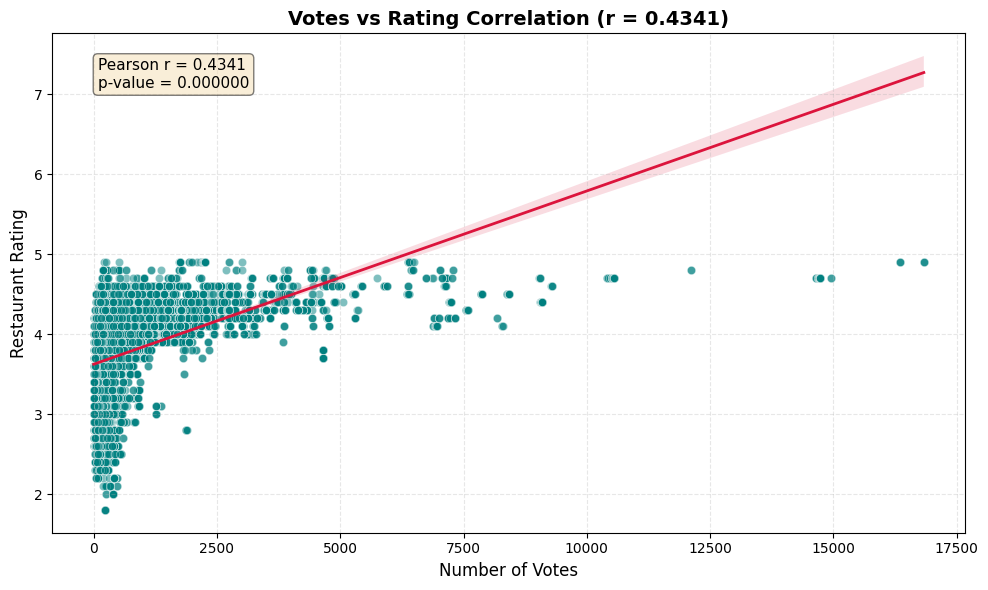

✅ Plot 1: Scatter plot saved as '1_scatter_votes_vs_rating.png'


In [ ]:
print("\n--- Generating Visualizations ---")
plt.figure(figsize=(10, 6))

sns.scatterplot(x='votes', y='rating', data=df_clean, alpha=0.5, color='teal')
sns.regplot(x='votes', y='rating', data=df_clean, scatter=False, color='crimson',
            ci=95, line_kws={'linewidth': 2})
plt.title(f'Votes vs Rating Correlation (r = {correlation:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Restaurant Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.text(0.05, 0.95, f'Pearson r = {correlation:.4f}\np-value = {p_value:.6f}',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('1_scatter_votes_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 1: Scatter plot saved as '1_scatter_votes_vs_rating.png'")


/tmp/ipykernel_1992/4206726792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vote_category', y='rating', data=df_clean, palette='Set3')


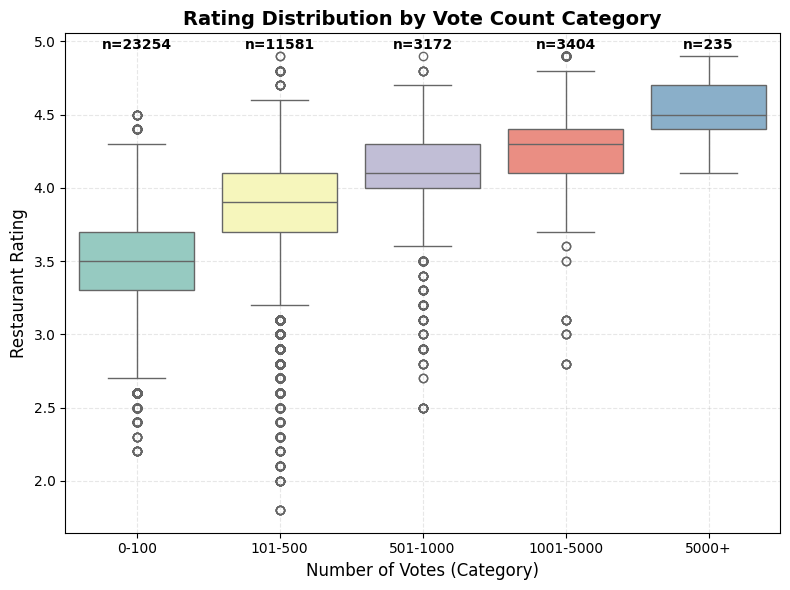

✅ Box plot saved as 'rating_by_vote_categories.png'


In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='vote_category', y='rating', data=df_clean, palette='Set3')
plt.title('Rating Distribution by Vote Count Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Votes (Category)', fontsize=12)
plt.ylabel('Restaurant Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

for i, category in enumerate(df_clean['vote_category'].cat.categories):
    count = len(df_clean[df_clean['vote_category'] == category])
    plt.text(i, df_clean['rating'].max() + 0.05, f'n={count}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('rating_by_vote_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Box plot saved as 'rating_by_vote_categories.png'")

/tmp/ipykernel_1992/3472127497.py:17: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1992/3472127497.py:18: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('3_top10_restaurants_by_votes.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


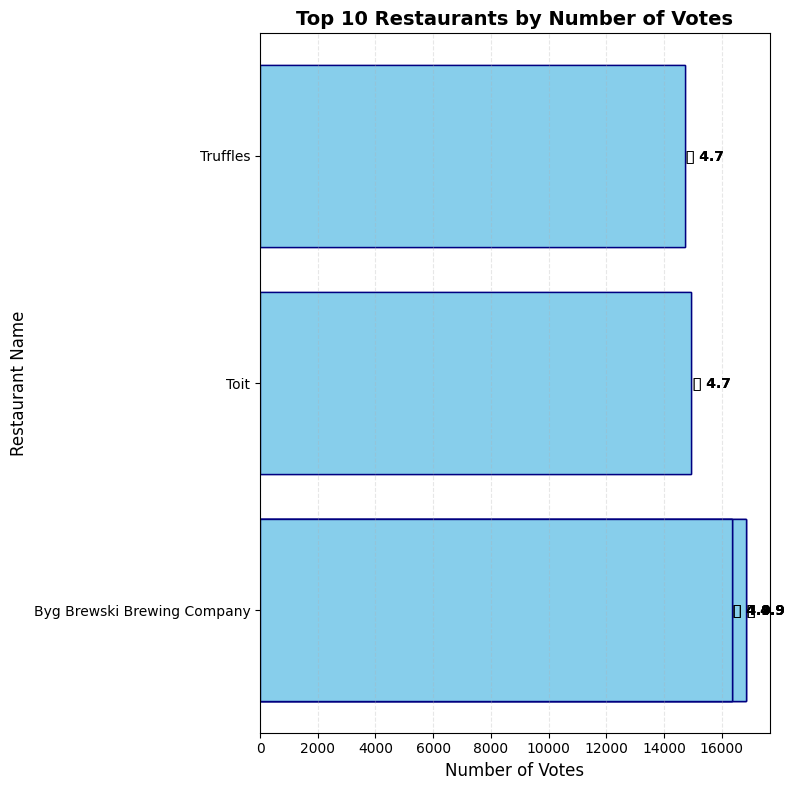

✅ Plot 3: Top 10 bar chart saved as '3_top10_restaurants_by_votes.png'


In [ ]:
plt.figure(figsize=(8,8))

top_10 = df_clean.nlargest(10, 'votes')[['name', 'votes', 'rating']]

# Create bar chart
bars = plt.barh(top_10['name'], top_10['votes'], color='skyblue', edgecolor='navy')
plt.title('Top 10 Restaurants by Number of Votes', fontsize=14, fontweight='bold')
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='x')

# Add rating labels on the bars
for i, (bar, rating) in enumerate(zip(bars, top_10['rating'])):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'⭐ {rating:.1f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('3_top10_restaurants_by_votes.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 3: Top 10 bar chart saved as '3_top10_restaurants_by_votes.png'")


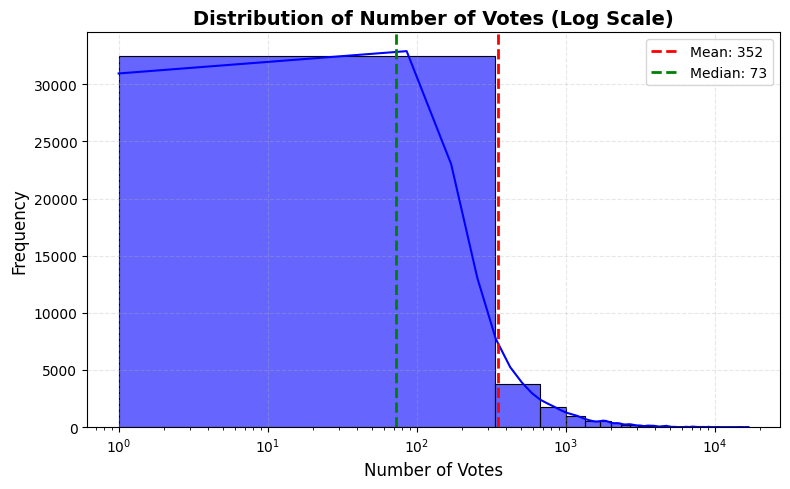

✅ Plot 4: Distribution chart saved as '4_votes_distribution.png'


In [ ]:
plt.figure(figsize=(8, 5))

# Log scale because votes are highly skewed
sns.histplot(df_clean['votes'], bins=50, kde=True, color='blue', alpha=0.6)
plt.title('Distribution of Number of Votes (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.3)

# Add statistics
mean_votes = df_clean['votes'].mean()
median_votes = df_clean['votes'].median()
plt.axvline(mean_votes, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_votes:.0f}')
plt.axvline(median_votes, color='green', linestyle='--', linewidth=2, label=f'Median: {median_votes:.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('4_votes_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Plot 4: Distribution chart saved as '4_votes_distribution.png'")

In [ ]:
print("\n" + "=" * 60)
print("📋 SUMMARY REPORT")
print("=" * 60)

print(f"""
Dataset analyzed: {csv_files[0]}
Total restaurants analyzed: {len(df_clean)}
""")


📋 SUMMARY REPORT

Dataset analyzed: zomato.csv
Total restaurants analyzed: 41646

